# 2. Core Workflows

Use this notebook when you want to see **what happens between your input geometry and the final Yamada polynomial** and, just as importantly, **which parameters you can change at each step**.

The example starts from a non-Hermitian exceptional surface and exposes the main intermediate objects:

$$ 
\text{surface}
\;\longrightarrow\;
\text{filled mask}
\;\longrightarrow\;
\text{skeleton points}
\;\longrightarrow\;
\text{raw graph}
\;\longrightarrow\;\\
\text{simplified graph}
\;\longrightarrow\;
\text{planar projection}
\;\longrightarrow\;
\text{PD code}
\;\longrightarrow\;
\text{Yamada polynomial}.
 
$$

You will learn how to inspect:

- the sampled surface/volume and grid resolution;
- leaf removal and degree-2 chain collapse;
- the **minimum-edge contraction cutoff**;
- edge smoothing tolerance;
- projection sampling and explicit rotations;
- the exact vertices, crossings, arcs, and PD code;
- Yamada options such as normalization, method, parallelism, and crossing warnings.

> **Important:** some controls below change the extracted embedded graph and can therefore affect the topology calculation. Others are display-only and only change how a figure looks. The notebook labels these separately.

## Set up the workflow

Run the setup cells once. They import the extraction, projection, invariant, and visualization tools used throughout this notebook.

> **Optional dependency:** this extraction example uses the `nodal` application stack, including PyVista, scikit-image, and poly2graph. Install it with `pip install "knotted_graph[nodal]"` if these imports are unavailable.

In [1]:
from pathlib import Path
import sys
import importlib.util
import os
import tempfile

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DOC_ROOT = PROJECT_ROOT / "doc"
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "knottedgraph-mpl"),
)

print("project paths configured")
for package in ["numpy", "networkx", "sympy", "plotly", "matplotlib", "pyvista"]:
    print(f"{package:10s} = {importlib.util.find_spec(package) is not None}")


project paths configured
numpy      = True
networkx   = True
sympy      = True
plotly     = True
matplotlib = True
pyvista    = True


In [ ]:
import math
import time

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import sympy as sp
from IPython.display import Math, display

from knotted_graph.projection import (
    compute_yamada_polynomial,
    sample_projections,
    select_projection,
)
from knotted_graph.visualization import plot_3D_graph_plotly

BLUE = "#1f77b4"
RED = "#d62728"
CAMERA = dict(eye=dict(x=4.0, y=4.0, z=3.0))
pio.renderers.default = "notebook_connected"
Y = sp.Symbol("Y")
kx, ky, kz = sp.symbols("k_x k_y k_z", real=True)


def axis_style():
    return dict(
        visible=True,
        title="",
        showticklabels=False,
        showbackground=False,
        showgrid=False,
        zeroline=False,
        showline=True,
        linecolor="black",
        linewidth=2,
    )


def apply_kg_layout(fig, *, width=760, height=620):
    fig.update_layout(
        title=None,
        width=width,
        height=height,
        margin=dict(l=0, r=0, t=0, b=0),
        scene=dict(
            xaxis=axis_style(),
            yaxis=axis_style(),
            zaxis=axis_style(),
            aspectmode="data",
            camera=CAMERA,
        ),
    )
    return fig


def plot_surface_polydata(surface, *, opacity=0.58):
    mesh = surface.triangulate()
    faces = mesh.faces.reshape(-1, 4)[:, 1:]
    pts = mesh.points
    fig = go.Figure(
        go.Mesh3d(
            x=pts[:, 0],
            y=pts[:, 1],
            z=pts[:, 2],
            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],
            color=BLUE,
            opacity=opacity,
        )
    )
    return apply_kg_layout(fig)


def plot_points_3d(points, *, size=3):
    points = np.asarray(points)
    fig = go.Figure(
        go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode="markers",
            marker=dict(size=size, color=BLUE),
        )
    )
    return apply_kg_layout(fig)


def plot_graph_kg(graph):
    return apply_kg_layout(plot_3D_graph_plotly(graph))


def graph_summary(label, graph):
    print(
        f"{label:20s}",
        "nodes_edges =",
        (graph.number_of_nodes(), graph.number_of_edges()),
        "degrees =",
        sorted(dict(graph.degree()).values()),
    )


def print_upsilon(label, expr):
    print(f"Upsilon({label}; Y) = {sp.expand(expr)}")


def display_bloch_vector(label, components):
    display(Math(label + r"=" + sp.latex(sp.Matrix(components))))


print("shared plotting and notation helpers ready")

def plot_projection_diagram(
    projection,
    *,
    title=None,
    annotate=False,
    figsize=(5.4, 4.6),
    edge_color=BLUE,
    vertex_color=RED,
    line_width=2.4,
    vertex_size=64,
    gap_fraction=0.015,
):
    """Draw blue edges, red vertices, and explicit over/under crossing gaps."""
    fig, ax = plt.subplots(figsize=figsize)

    arcs_by_id = {
        arc.id: arc
        for arc in projection.arcs
    }

    all_xy = []

    # Draw the complete projected diagram first.
    for arc in projection.arcs:
        x, y = arc.line.xy
        ax.plot(
            x,
            y,
            color=edge_color,
            linewidth=line_width,
            solid_capstyle="round",
            zorder=1,
        )
        all_xy.extend(zip(x, y))

        if annotate:
            midpoint = arc.line.interpolate(
                0.5,
                normalized=True,
            )
            ax.text(
                midpoint.x,
                midpoint.y,
                f"a{arc.id}",
                fontsize=8,
                color=edge_color,
                zorder=7,
            )

    if all_xy:
        xy = np.asarray(
            all_xy,
            dtype=float,
        )
        diagram_span = max(
            float(np.ptp(xy[:, 0])),
            float(np.ptp(xy[:, 1])),
            1.0,
        )
    else:
        diagram_span = 1.0

    gap_radius = (
        gap_fraction
        * diagram_span
    )

    for crossing in projection.crossings:
        try:
            ordered_arcs = list(
                crossing.ccw_ordered_arcs
            )
        except Exception:
            ordered_arcs = []

        if len(ordered_arcs) != 4:
            continue

        cx = crossing.point.x
        cy = crossing.point.y

        # Temporarily erase both strands around the crossing.
        ax.add_patch(
            plt.Circle(
                (cx, cy),
                gap_radius,
                facecolor="white",
                edgecolor="none",
                zorder=4,
            )
        )

        # In KnottedGraph's crossing order, entries 0 and 2 form
        # the over-strand. Redraw those two half-arcs continuously.
        for arc_id in (
            ordered_arcs[0],
            ordered_arcs[2],
        ):
            arc = arcs_by_id.get(
                arc_id
            )

            if (
                arc is None
                or arc.line.length <= 0
            ):
                continue

            probe_distance = min(
                2.4 * gap_radius,
                0.45 * arc.line.length,
            )

            if (
                arc.start_type == "x"
                and arc.start_id
                == crossing.id
            ):
                outside_point = (
                    arc.line.interpolate(
                        probe_distance
                    )
                )

            elif (
                arc.end_type == "x"
                and arc.end_id
                == crossing.id
            ):
                outside_point = (
                    arc.line.interpolate(
                        max(
                            arc.line.length
                            - probe_distance,
                            0.0,
                        )
                    )
                )

            else:
                continue

            ax.plot(
                [cx, outside_point.x],
                [cy, outside_point.y],
                color=edge_color,
                linewidth=line_width,
                solid_capstyle="round",
                zorder=5,
            )

        if annotate:
            ax.annotate(
                f"x{crossing.id}",
                (cx, cy),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
                color="black",
                zorder=8,
            )

    # Rigid graph vertices are always red.
    for vertex in projection.vertices:
        ax.scatter(
            *vertex.point.xy,
            color=vertex_color,
            s=vertex_size,
            zorder=6,
        )

        if annotate:
            ax.annotate(
                f"v{vertex.id}",
                vertex.point.xy,
                xytext=(5, -10),
                textcoords="offset points",
                fontsize=8,
                color=vertex_color,
                zorder=8,
            )

    ax.set_aspect("equal")
    ax.axis("off")

    if title:
        ax.set_title(title)

    plt.show()
    return fig, ax

## 2.1 Choose the input geometry and sampling resolution

These are the **first topology-sensitive controls**. If the grid is too coarse, thin branches can disappear or merge before graph extraction even starts.

- `INSPECTION_GAMMA` changes the physical model used in this example.
- `GRID_DIMENSION` controls the number of grid samples along each momentum axis. Larger values resolve finer geometry but cost more memory and time.
- `K_SPAN` chooses the sampled region of momentum space.
- `AXIS_SCALE` rescales the coordinate axes used by the nodal helper.

The last group contains **display-only controls**. They do not change the extracted graph.

In [3]:
# ---------------------------
# INPUT / SAMPLING CONTROLS
# ---------------------------
INSPECTION_GAMMA = 0.20
GRID_DIMENSION = 300
K_SPAN = ((-np.pi, np.pi), (-np.pi, np.pi), (0, np.pi))
AXIS_SCALE = (1.0, 1.0, 1.0)

# ---------------------------
# DISPLAY-ONLY CONTROLS
# ---------------------------
SURFACE_OPACITY = 0.58
MASK_POINT_SIZE = 2
SKELETON_POINT_SIZE = 3
MAX_MASK_POINTS_TO_DISPLAY = 4500
DISPLAY_RANDOM_SEED = 5

print("grid dimension =", GRID_DIMENSION)
print("k-space span =", K_SPAN)


grid dimension = 300
k-space span = ((-3.141592653589793, 3.141592653589793), (-3.141592653589793, 3.141592653589793), (0, 3.141592653589793))


### Build the surface, filled mask, and raw skeleton

This cell intentionally stops **before graph cleanup**. That makes the raw extraction independent of later simplification choices.

If the surface or skeleton already looks wrong, change the model, span, or resolution above rather than trying to repair the problem with graph simplification later.

The built-in nodal constructors define a two-band non-Hermitian Hamiltonian from a
complex polynomial $f(z,w)$.  They first return the Bloch vector

$$
\mathbf d_f(\mathbf k)
=
\left(
\operatorname{Re}f,\,
i\gamma,\,
\operatorname{Im}f
\right),
$$

and `NodalSkeleton` constructs

$$
H_f(\mathbf k;\gamma)
=
\mathbf d_f(\mathbf k)\cdot\boldsymbol{\sigma}
=
\begin{pmatrix}
\operatorname{Im}f & \operatorname{Re}f+\gamma\\
\operatorname{Re}f-\gamma & -\operatorname{Im}f
\end{pmatrix}.
$$

Unless a model explicitly overrides them,

$$
z
=
\cos(2k_z)+c
+i\left(
\cos k_x+\cos k_y+\cos k_z-m
\right),
\qquad
w
=
\sin k_x+i\sin k_y.
$$

For the three-link model,

$$
f_{\mathrm{3L}}(z,w)
=
z\left(z^2-w^2\right),
\qquad
c=0.5,\quad m=2.
$$

In [4]:
from skimage import morphology

from knotted_graph.applications.nodal import NodalSkeleton
from knotted_graph.applications.nodal.models import threelink_bloch_vector
from knotted_graph.core import (
    contract_short_edges,
    idx_to_coord,
    remove_leaf_nodes,
    simplify_edges,
    smooth_edges,
)
from knotted_graph.extraction import skeleton_image_to_graph


def graph_indices_to_kspace(index_graph, skeleton):
    graph_kspace = nx.MultiGraph()
    for node, data in index_graph.nodes(data=True):
        attrs = dict(data)
        attrs["pos"] = idx_to_coord(
            attrs["pos"], spacing=skeleton.spacing, origin=skeleton.origin
        )
        graph_kspace.add_node(node, **attrs)

    for u, v, key, data in index_graph.edges(keys=True, data=True):
        attrs = dict(data)
        if attrs.get("pts") is not None:
            attrs["pts"] = idx_to_coord(
                attrs["pts"], spacing=skeleton.spacing, origin=skeleton.origin
            )
        graph_kspace.add_edge(u, v, key=key, **attrs)

    graph_kspace.graph.update(index_graph.graph)
    return graph_kspace


inspection_model = threelink_bloch_vector(
    INSPECTION_GAMMA,
    k_symbols=(kx, ky, kz),
)
display_bloch_vector(r"d_{\mathrm{3Link}}(\mathbf{k})", inspection_model)

ske = NodalSkeleton(
    inspection_model,
    k_symbols=(kx, ky, kz),
    span=K_SPAN,
    dimension=GRID_DIMENSION,
    axis_scale=AXIS_SCALE,
)

surface = ske.exceptional_surface_pv
filled_mask = ske._interior_mask
skeleton_image = morphology.skeletonize(filled_mask, method="lee")

raw_graph_index = skeleton_image_to_graph(skeleton_image)
raw_graph = graph_indices_to_kspace(raw_graph_index, ske)

rng = np.random.default_rng(DISPLAY_RANDOM_SEED)
mask_indices = np.column_stack(np.where(filled_mask))
mask_indices = mask_indices[
    rng.choice(
        len(mask_indices),
        size=min(MAX_MASK_POINTS_TO_DISPLAY, len(mask_indices)),
        replace=False,
    )
]
filled_mask_points = idx_to_coord(
    mask_indices,
    spacing=ske.spacing,
    origin=ske.origin,
)
skeleton_points = idx_to_coord(
    np.column_stack(np.where(skeleton_image)),
    spacing=ske.spacing,
    origin=ske.origin,
)

print("surface_points_cells =", (surface.n_points, surface.n_cells))
print("filled_mask_voxels =", int(filled_mask.sum()))
print("skeleton_voxels =", int(skeleton_image.sum()))
graph_summary("raw graph", raw_graph)


<IPython.core.display.Math object>

surface_points_cells = (96816, 193636)
filled_mask_voxels = 591340
skeleton_voxels = 947
raw graph            nodes_edges = (37, 38) degrees = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4]


### Check the surface

This is the finite-thickness object from which the interior mask is generated.

Before continuing, confirm that the surface has the branches, junctions, and connected components you intend to classify. `SURFACE_OPACITY` below is **display-only**.

In [5]:
fig = plot_surface_polydata(surface, opacity=SURFACE_OPACITY)
fig.show()


### Check the filled interior

The figure shows a random subset of occupied voxels for readability. The full boolean mask remains available as `filled_mask`.

Use this view to catch holes, disconnected regions, or grid-resolution artifacts before skeletonization. `MAX_MASK_POINTS_TO_DISPLAY` and `MASK_POINT_SIZE` affect only the visualization. This also allows one to understand if the selected 'GRID_DIMENSION' is enough to preserve the topology.

In [6]:
fig = plot_points_3d(filled_mask_points, size=MASK_POINT_SIZE)
fig.show()


### Check the skeleton points

These points are the voxel skeleton **before graph simplification**.

Look for spurious short branches, missing connections, and resolution-dependent features. If a branch is absent here, changing a later edge cutoff cannot restore it; revisit `GRID_DIMENSION`, `K_SPAN`, or the input model.

In [7]:
fig = plot_points_3d(skeleton_points, size=SKELETON_POINT_SIZE)
fig.show()


## 2.2 Simplify the graph one operation at a time

The next cells are intentionally split so that every important transformation is visible next to its parameter.

A useful debugging rule is:

1. plot the graph before an operation;
2. apply exactly one operation;
3. print the node/edge counts;
4. plot again;
5. only then continue.

This makes it clear which operation changed the connectivity or geometry.

### Raw graph

This is the graph returned directly by `skeleton_image_to_graph(...)`, converted from voxel-index coordinates to the physical $k$-space coordinates used in this notebook.

The plotting controls below are **display-only**.

In [8]:
fig = plot_graph_kg(raw_graph)
fig.show()


### Step A — remove degree-1 leaves

`remove_leaf_nodes(...)` repeatedly removes degree-1 branches. This is a **structural** operation: a genuine terminal branch will also be removed.

There is no numerical threshold in this function. The user-facing choice is simply whether to perform the operation.

Set `REMOVE_LEAVES = False` when terminal branches are meaningful in your application.

In [9]:
REMOVE_LEAVES = True

if REMOVE_LEAVES:
    leaf_removed_graph_index = remove_leaf_nodes(raw_graph_index)
else:
    leaf_removed_graph_index = raw_graph_index.copy()

leaf_removed_graph = graph_indices_to_kspace(leaf_removed_graph_index, ske)
graph_summary("after leaf removal", leaf_removed_graph)

fig = plot_graph_kg(leaf_removed_graph)
fig.show()


after leaf removal   nodes_edges = (17, 18) degrees = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3]


### Step B — collapse degree-2 chains

`simplify_edges(...)` replaces chains of degree-2 graph nodes by a single embedded edge while preserving the edge polyline.

This primarily simplifies the **graph representation** rather than imposing a geometric length cutoff. If you want to remove/contract geometrically short edges, use the next step instead.

Set `COLLAPSE_DEGREE2_CHAINS = False` if you need to retain every intermediate graph node.

In [10]:
COLLAPSE_DEGREE2_CHAINS = True

if COLLAPSE_DEGREE2_CHAINS:
    chain_collapsed_graph_index = simplify_edges(leaf_removed_graph_index)
else:
    chain_collapsed_graph_index = leaf_removed_graph_index.copy()

chain_collapsed_graph = graph_indices_to_kspace(chain_collapsed_graph_index, ske)
graph_summary("after chain collapse", chain_collapsed_graph)

fig = plot_graph_kg(chain_collapsed_graph)
fig.show()


after chain collapse nodes_edges = (2, 3) degrees = [3, 3]


### Step C — choose the minimum-edge contraction cutoff

This is one of the most important knobs that was easy to miss in the compact workflow.

```python
contract_short_edges(graph, min_length=MIN_EDGE_LENGTH)
```

`MIN_EDGE_LENGTH` is the cutoff used to contract sufficiently short edges. In this manual workflow the graph has already been converted to $k$-space, so choose the cutoff in the coordinate scale of `chain_collapsed_graph`.

- **Smaller cutoff** → more conservative; preserves more short edges.
- **Larger cutoff** → more aggressive; contracts more short edges.
- `None` → skip this operation entirely.

Do not tune this value merely to obtain a preferred polynomial. Choose it from geometric/numerical considerations and verify the graph visually before computing topology.

In [11]:
# ---------------------------
# IMPORTANT STRUCTURAL KNOB
# ---------------------------
MIN_EDGE_LENGTH = 0.40   # try a smaller/larger value, or None to skip contraction

if MIN_EDGE_LENGTH is None:
    contracted_graph = chain_collapsed_graph.copy()
else:
    contracted_graph = contract_short_edges(
        chain_collapsed_graph,
        min_length=MIN_EDGE_LENGTH,
    )

graph_summary("after contraction", contracted_graph)

fig = plot_graph_kg(contracted_graph)
fig.show()


after contraction    nodes_edges = (2, 3) degrees = [3, 3]


### Step D — smooth edge polylines

`smooth_edges(..., epsilon=...)` applies geometric polyline simplification. The parameter `epsilon` is therefore a **geometric fidelity knob**:

- smaller `SMOOTH_EPSILON` keeps more polyline detail;
- larger `SMOOTH_EPSILON` removes more small-scale bends/points;
- `0` is the conservative limit.

Smoothing should not be used to repair wrong connectivity. Always inspect the contracted graph first.

In [12]:
SMOOTH_EPSILON = 0.08

processed_graph = smooth_edges(
    contracted_graph,
    epsilon=SMOOTH_EPSILON,
    copy=True,
)

graph_summary("after smoothing", processed_graph)

fig = plot_graph_kg(processed_graph)
fig.show()


after smoothing      nodes_edges = (2, 3) degrees = [3, 3]


### Compare the complete cleanup sequence numerically

The plot is the primary check, but node/edge counts make the effect of each operation explicit and reproducible.

In [13]:
stage_graphs = [
    ("raw graph", raw_graph),
    ("leaf removal", leaf_removed_graph),
    ("chain collapse", chain_collapsed_graph),
    ("edge contraction", contracted_graph),
    ("smoothing", processed_graph),
]

for name, stage_graph in stage_graphs:
    graph_summary(name, stage_graph)


raw graph            nodes_edges = (37, 38) degrees = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4]
leaf removal         nodes_edges = (17, 18) degrees = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3]
chain collapse       nodes_edges = (2, 3) degrees = [3, 3]
edge contraction     nodes_edges = (2, 3) degrees = [3, 3]
smoothing            nodes_edges = (2, 3) degrees = [3, 3]


## 2.3 Use the high-level skeleton helper when you do not need manual control

Once you understand the individual stages, `NodalSkeleton.skeleton_graph(...)` is convenient for the standard path.

The user-facing parameters are:

- `simplify=True/False` — whether leaf removal and degree-2 chain simplification are applied;
- `smooth_epsilon=...` — smoothing tolerance;
- `skeleton_image=...` — optionally supply an externally prepared skeleton image.

The manual workflow remains preferable when you need to insert extra operations such as an explicit short-edge contraction cutoff.

> **Units matter:** the high-level helper operates on its skeleton graph before the manual conversion to $k$-space used above, so do not assume that its `smooth_epsilon` should have the same numerical value as `SMOOTH_EPSILON` in the manual $k$-space workflow.

In [14]:
HIGH_LEVEL_SIMPLIFY = True
HIGH_LEVEL_SMOOTH_EPSILON = 2

standard_graph = ske.skeleton_graph(
    simplify=HIGH_LEVEL_SIMPLIFY,
    smooth_epsilon=HIGH_LEVEL_SMOOTH_EPSILON,
)
standard_graph_kspace = graph_indices_to_kspace(standard_graph, ske)

print(
    "standard high-level graph =",
    (standard_graph_kspace.number_of_nodes(), standard_graph_kspace.number_of_edges()),
)
print(
    "manual processed graph =",
    (processed_graph.number_of_nodes(), processed_graph.number_of_edges()),
)

fig = plot_graph_kg(standard_graph_kspace)
fig.show()


standard high-level graph = (2, 3)
manual processed graph = (2, 3)


## 2.4 Choose and inspect a planar projection

The 3D embedded graph must be projected to a planar diagram before generating a PD code.

There are two common workflows:

**Automatic selection**

```python
projection = select_projection(
    graph,
    num_rotation_samples=24,
    rotation_order="ZYX",
)
```

The library samples candidate orientations and selects a valid projection with the fewest crossings.

**Explicit orientation**

```python
projection = select_projection(
    graph,
    rotation_angles=(30, 45, 0),
    rotation_order="ZYX",
)
```

Use this when you want exact reproducibility or want to inspect a specific viewing direction. Angles are in degrees for the current rotation helpers.

In [15]:
# ---------------------------
# PROJECTION CONTROLS
# ---------------------------
PROJECTION_SAMPLES = 16
ROTATION_ORDER = "ZYX"
EXPLICIT_ROTATION = None   # e.g. (30.0, 45.0, 0.0); keep None for automatic selection

if EXPLICIT_ROTATION is None:
    projection_inspection = select_projection(
        processed_graph,
        num_rotation_samples=PROJECTION_SAMPLES,
        rotation_order=ROTATION_ORDER,
    )
else:
    projection_inspection = select_projection(
        processed_graph,
        rotation_angles=EXPLICIT_ROTATION,
        rotation_order=ROTATION_ORDER,
    )

print("selected rotation =", projection_inspection.rotation_angles)
print("rotation order =", projection_inspection.rotation_order)
print("crossings =", projection_inspection.num_crossings)


selected rotation = (0.0, 88.20921534067105, 0.0)
rotation order = ZYX
crossings = 1


### Inspect vertices, crossings, and arcs

The projection object separates the planar diagram into:

- **vertices** — projected graph vertices with rigid-vertex ordering data;
- **crossings** — over/under intersections created by the projection;
- **arcs** — planar segments joining vertices and crossings.

Plot these objects before computing the invariant. A poor or nearly degenerate projection is much easier to diagnose visually than from a polynomial alone.

The projection uses **blue edges, red graph vertices, and an explicit break in the
under-strand**.  A black “x” is not used as a substitute for crossing information.

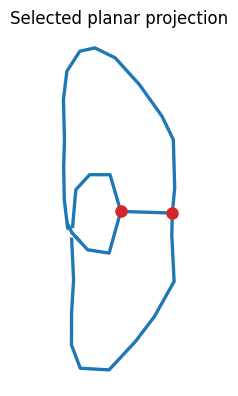

(<Figure size 540x460 with 1 Axes>,
 <Axes: title={'center': 'Selected planar projection'}>)

In [16]:
plot_projection_diagram(
    projection_inspection,
    title="Selected planar projection",
)

## 2.5 Read the exact PD-code data

The next cell prints the exact rotation, crossing count, vertex records, crossing coordinates, arc endpoints, and PD code.

Save this information whenever reproducibility matters. If two calculations give different answers, comparing these diagram-level records tells you whether the difference appeared before or during the invariant calculation.

In [17]:
print(
    "rotation_angles =",
    tuple(round(a, 2) for a in projection_inspection.rotation_angles),
)
print("rotation_order =", projection_inspection.rotation_order)
print("crossings =", projection_inspection.num_crossings)
print("pd_code =", projection_inspection.pd_code)
print("vertices =", [(v.id, v.key) for v in projection_inspection.vertices])
print(
    "crossing_points =",
    [
        (x.id, tuple(round(c, 3) for c in tuple(x.point.coords)[0]))
        for x in projection_inspection.crossings
    ],
)
print(
    "arcs =",
    [
        (arc.id, arc.start_type, arc.start_id, arc.end_type, arc.end_id)
        for arc in projection_inspection.arcs
    ],
)


rotation_angles = (0.0, 88.21, 0.0)
rotation_order = ZYX
crossings = 1
pd_code = V[0,3,2];V[4,2,1];X[4,1,3,0]
vertices = [(0, 0), (1, 1)]
crossing_points = [(0, (0.584, -0.26))]
arcs = [(0, 'v', 0, 'x', 0), (1, 'x', 0, 'v', 1), (2, 'v', 0, 'v', 1), (3, 'v', 0, 'x', 0), (4, 'x', 0, 'v', 1)]


## 2.6 Compare alternative projections

Increase `NUM_PROJECTIONS_TO_COMPARE` when you want a broader robustness check. More samples cost more projection work but can reveal whether a particularly simple or problematic viewing direction is being selected.

A change of viewing direction changes the **diagram**, not the underlying embedded spatial graph. For a stable workflow, equivalent valid projections should be consistent with the same spatial-graph topology.

In [18]:
NUM_PROJECTIONS_TO_COMPARE = 12
SHOW_FIRST_N = 5

projections = sample_projections(
    processed_graph,
    num_rotation_samples=NUM_PROJECTIONS_TO_COMPARE,
    rotation_order=ROTATION_ORDER,
)
summary = sorted(
    [
        (
            idx,
            p.num_crossings,
            tuple(round(a, 2) for a in p.rotation_angles),
            p.pd_code,
        )
        for idx, p in enumerate(projections)
    ],
    key=lambda row: (row[1], row[0]),
)

for idx, crossings, angles, pd_code in summary[:SHOW_FIRST_N]:
    print(f"projection[{idx}] crossings={crossings} angles={angles}")
    print(pd_code)


projection[0] crossings=1 angles=(0.0, 87.61, 0.0)
V[0,3,2];V[4,2,1];X[4,1,3,0]
projection[1] crossings=1 angles=(137.51, 82.82, 0.0)
V[3,2,0];V[1,4,2];X[3,0,4,1]
projection[2] crossings=1 angles=(-84.98, 77.98, 0.0)
V[3,2,0];V[2,1,4];X[4,1,3,0]
projection[3] crossings=1 angles=(52.52, 73.04, 0.0)
V[2,0,3];V[4,2,1];X[3,0,4,1]
projection[4] crossings=1 angles=(-169.97, 67.98, 0.0)
V[3,2,0];V[2,1,4];X[4,1,3,0]


## 2.7 Compute the Yamada polynomial from the projection you inspected

Pass the selected rotation angles explicitly so the invariant call cannot silently switch to another sampled projection.

The main user-facing controls are:

- `NORMALIZE_YAMADA` — use the normalized convention when `True`;
- `YAMADA_METHOD` — invariant computation backend/method, currently shown with `"negami"`;
- `N_JOBS` — parallel worker setting; `1` is reproducible and notebook-friendly;
- `CROSSING_WARNING_THRESHOLD` — warn when the selected diagram has many crossings and may be expensive;
- `return_result=True` — return both the polynomial and the exact projection metadata used.

For a quick calculation where you do **not** care which projection was selected, you can omit `rotation_angles` and let `compute_yamada_polynomial(...)` perform automatic projection selection using `num_rotation_samples`.

In [19]:
NORMALIZE_YAMADA = True
YAMADA_METHOD = "negami"
N_JOBS = 1
CROSSING_WARNING_THRESHOLD = 10

core_result = compute_yamada_polynomial(
    processed_graph,
    Y,
    rotation_angles=projection_inspection.rotation_angles,
    rotation_order=projection_inspection.rotation_order,
    crossing_warning_threshold=CROSSING_WARNING_THRESHOLD,
    normalize=NORMALIZE_YAMADA,
    n_jobs=N_JOBS,
    method=YAMADA_METHOD,
    return_result=True,
)

print_upsilon("G_processed", core_result.polynomial)
print("rotation used =", core_result.projection.rotation_angles)
print("PD code used =", core_result.projection.pd_code)


Upsilon(G_processed; Y) = -Y**4 - Y**3 - 2*Y**2 - Y - 1
rotation used = (0.0, 88.20921534067105, 0.0)
PD code used = V[0,3,2];V[4,2,1];X[4,1,3,0]


## 2.8 A compact “what should I change?” guide

| Symptom | First control to inspect | Why |
|---|---|---|
| A branch is missing already in the surface/mask | `GRID_DIMENSION`, `K_SPAN`, input model | The geometry was not sampled/resolved correctly. |
| A terminal branch disappears | `REMOVE_LEAVES` | Leaf removal is structural and intentionally removes degree-1 branches. |
| Too many intermediate graph nodes | `COLLAPSE_DEGREE2_CHAINS` | Degree-2 chains can be represented as one embedded edge. |
| Tiny graph edges create unwanted local structure | `MIN_EDGE_LENGTH` | This is the explicit short-edge contraction cutoff. |
| Edge polylines are excessively jagged/dense | `SMOOTH_EPSILON` | Controls geometric polyline simplification. |
| Projection is cluttered | `PROJECTION_SAMPLES` or `EXPLICIT_ROTATION` | Search more orientations or lock a known clean one. |
| Yamada computation becomes expensive | projection crossing count, `CROSSING_WARNING_THRESHOLD`, `N_JOBS` | State complexity grows rapidly with diagram complexity. |
| Surface or point-cloud display is hard to read | point sizes or opacity | These controls are display-only and do not alter the extracted graph. |

The key principle is to adjust the **earliest stage at which the problem appears** rather than compensating at a later stage.

## 2.9 Before interpreting a difference as topology

If two runs produce different polynomials, check the pipeline in this order:

1. Confirm that both sampled surfaces/masks represent the intended geometry.
2. Confirm that both raw skeleton graphs have the intended connectivity.
3. Check whether leaf removal changed a meaningful terminal branch.
4. Record and compare `MIN_EDGE_LENGTH` and the graph immediately before/after contraction.
5. Record and compare `SMOOTH_EPSILON` and verify that smoothing preserved the intended embedding.
6. Confirm that the selected projections are valid and nondegenerate.
7. Verify that each printed PD code matches the diagram you inspected.
8. Compare Yamada results using the same normalization, method, and projection convention.

Only after these checks should you interpret a difference as evidence of different spatial-graph topology.

For lower-level state expansion and projection robustness tests, continue to **[3. Advanced & Reproduction](03_advanced_and_reproduction.ipynb)**.